In [1]:
import os
import sys

project_root = "/root/work/tvm-ansor"
os.environ["TVM_HOME"] = f"{project_root}"
os.environ["TVM_LIBRARY_PATH"] = f"{project_root}/build-release"
if f"{project_root}/python" not in sys.path:
    sys.path.insert(0, f"{project_root}/python")

sys.path = [p for p in sys.path if not p.startswith(f"{project_root}/build")]
sys.path.append(f"{project_root}/build-release")
os.environ["LD_LIBRARY_PATH"] = f"{project_root}/build-release:" + os.environ.get("LD_LIBRARY_PATH", "")


import tvm

TARGET = tvm.target.Target("cuda")


In [2]:
import numpy as np


from tvm import auto_scheduler
from util_modules.task_paths import load_and_register_tasks
import numpy as np
import importlib
# importlib.reload(sys.modules["util_modules.plot.latent_cost_geometry"])

tasks = load_and_register_tasks()


/root/work/tvm-ansor/gallery/constrained_gen/data/measured_family_ansor/302_([72858abe65e3185202b62d45a3956c75,[1,8,8,128],[6,6,32,128],[1,8,8,32]],cuda).json
Task 302: vm_mod_fused_nn_contrib_conv2d_winograd_without_weight_transform_3 ["72858abe65e3185202b62d45a3956c75", [1, 8, 8, 128], [6, 6, 32, 128], [1, 8, 8, 32]]


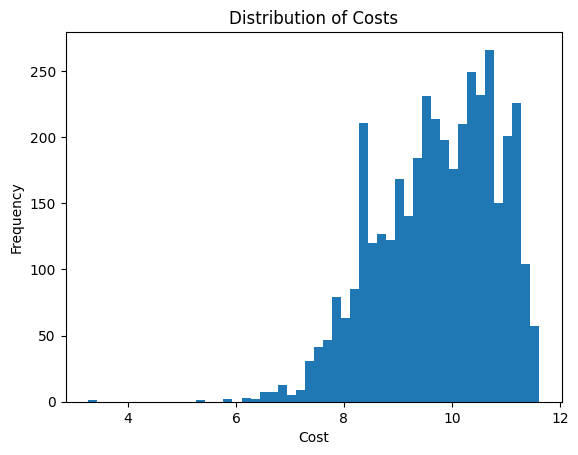

In [3]:
from util_modules.input.integrated import json_to_VecCosts
from util_modules.plot.cost_dist import plot_cost_distribution
from glob import glob
importlib.reload(sys.modules["util_modules.input.integrated"])

json_files = [
    "/root/work/tvm-ansor/gallery/constrained_gen/data/measured_ansor/584_([cb7a0e9e733d26ffc00e7f6c9cc0f879,[1,128,128,32],[1,1,32,16],[1,1,1,16],[1,128,128,16]],cuda).json",
    # "/root/work/tvm-ansor/gallery/constrained_gen/data/measured_ansor/1490_([3eda1939e30b947e921f5e1814346365,[1,56,56,128],[6,6,32,128],[1,56,56,32]],cuda).json"
]
json_files = glob("/root/work/tvm-ansor/gallery/constrained_gen/data/measured_*/302*.json")

for json_file in json_files:
    print(f"{json_file}")
    task_idx = json_file.split('/')[-1].split('_')[0]
    task = tasks[int(task_idx)]
    print(f"Task {task_idx}: {task.desc} {task.workload_key}")

    try:
        raw_sch, costs, raw_costs = json_to_VecCosts(json_file, type="schedules", return_raw_cost=True)
    except Exception as e:
        print(f"Error occurred while processing {json_file}: {e}")
        continue
    # raw_features, costs = json_to_VecCosts(json_file, type="features")
    # features = raw_features.sum(axis=1)
    # raw_extents, costs = json_to_VecCosts(json_file, type="extents")


    

    plot_cost_distribution(costs)

    # sorted(costs)

In [4]:
sorted(costs, reverse=True)

[11.61680448599078,
 11.616337140111206,
 11.609991218225563,
 11.607259221630823,
 11.60118161637017,
 11.600694219607005,
 11.59574201619316,
 11.59344486957903,
 11.591972640572523,
 11.564364033067388,
 11.556236666107402,
 11.548114741960099,
 11.54291639723317,
 11.539822981575883,
 11.5376601951142,
 11.533922365126427,
 11.531076197396319,
 11.527998494467749,
 11.527990373003124,
 11.527880062974308,
 11.524368352465434,
 11.523247891709152,
 11.520847091702544,
 11.518610259505671,
 11.515931311336791,
 11.514872358938973,
 11.51458283765388,
 11.511169673940488,
 11.50726153534579,
 11.506963274206012,
 11.501589955306484,
 11.497964605496863,
 11.493466033814009,
 11.48858413358407,
 11.484739773298456,
 11.483758325178927,
 11.483175742443795,
 11.479764743196823,
 11.476165790510413,
 11.474519185942505,
 11.471969079480845,
 11.469211655779445,
 11.468028584087946,
 11.467385019867018,
 11.46734998617894,
 11.464487743853933,
 11.463351481083619,
 11.462977241451714,
 11

In [5]:
sorted(raw_costs)

[9.013343333333333e-06,
 9.017556666666667e-06,
 9.074963333333334e-06,
 9.099789999999998e-06,
 9.155263333333334e-06,
 9.159726666666667e-06,
 9.2052e-06,
 9.22637e-06,
 9.239963333333333e-06,
 9.49862e-06,
 9.576133333333333e-06,
 9.654226666666666e-06,
 9.704543333333334e-06,
 9.73461e-06,
 9.755686666666667e-06,
 9.79222e-06,
 9.82013e-06,
 9.850399999999998e-06,
 9.85048e-06,
 9.851566666666666e-06,
 9.886223333333333e-06,
 9.897306666666667e-06,
 9.921096666666666e-06,
 9.943313333333334e-06,
 9.969986666666667e-06,
 9.98055e-06,
 9.983440000000001e-06,
 1.0017573333333333e-05,
 1.00568e-05,
 1.00598e-05,
 1.0114e-05,
 1.0150733333333333e-05,
 1.0196500000000001e-05,
 1.0246400000000002e-05,
 1.0285866666666668e-05,
 1.0295966666666666e-05,
 1.0301966666666666e-05,
 1.0337166666666666e-05,
 1.0374436666666667e-05,
 1.0391533333333332e-05,
 1.0418066666666668e-05,
 1.0446833333333335e-05,
 1.0459200000000001e-05,
 1.0465933333333333e-05,
 1.04663e-05,
 1.0496300000000001e-05,
 1.